In [1]:
import sys
!{sys.executable} -m pip install librosa pywavelets torchaudio torchvision

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import numpy as np
import librosa
import pywt
import torch
import torchaudio
import torchvision.transforms as transforms
from pathlib import Path

print("All imports successful!")
print(f"Torch version: {torch.__version__}")
print(f"Torchaudio version: {torchaudio.__version__}")
print(f"Librosa version: {librosa.__version__}")

All imports successful!
Torch version: 2.8.0+cu128
Torchaudio version: 2.8.0+cu128
Librosa version: 0.11.0


In [3]:
# Base dataset path
BASE_PATH = "LA"

TRAIN_AUDIO = os.path.join(BASE_PATH, "ASVspoof2019_LA_train/flac")
DEV_AUDIO   = os.path.join(BASE_PATH, "ASVspoof2019_LA_dev/flac")
EVAL_AUDIO  = os.path.join(BASE_PATH, "ASVspoof2019_LA_eval/flac")

TRAIN_PROTOCOL = os.path.join(BASE_PATH, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt")
DEV_PROTOCOL   = os.path.join(BASE_PATH, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt")
EVAL_PROTOCOL  = os.path.join(BASE_PATH, "ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt")

# Verify paths exist
for path in [TRAIN_AUDIO, DEV_AUDIO, EVAL_AUDIO, TRAIN_PROTOCOL, DEV_PROTOCOL, EVAL_PROTOCOL]:
    status = "✅" if os.path.exists(path) else "❌"
    print(f"{status} {path}")

✅ LA/ASVspoof2019_LA_train/flac
✅ LA/ASVspoof2019_LA_dev/flac
✅ LA/ASVspoof2019_LA_eval/flac
✅ LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
✅ LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
✅ LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt


In [4]:
def load_protocol(protocol_path):
    labels = {}
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            file_id = parts[1]       # audio filename
            label   = parts[4]       # "bonafide" or "spoof"
            labels[file_id] = 1 if label == "bonafide" else 0
    return labels

train_labels = load_protocol(TRAIN_PROTOCOL)
dev_labels   = load_protocol(DEV_PROTOCOL)
eval_labels  = load_protocol(EVAL_PROTOCOL)

print(f"Train samples : {len(train_labels)}")
print(f"Dev samples   : {len(dev_labels)}")
print(f"Eval samples  : {len(eval_labels)}")

# Show sample
sample = list(train_labels.items())[:3]
for file_id, label in sample:
    print(f"  {file_id} → {'bonafide' if label==1 else 'spoof'}")

Train samples : 25380
Dev samples   : 24844
Eval samples  : 71237
  LA_T_1138215 → bonafide
  LA_T_1271820 → bonafide
  LA_T_1272637 → bonafide


In [5]:
SAMPLE_RATE = 16000       # 16kHz standard for speech
SEGMENT_LEN = 2           # 2 seconds as per paper
SAMPLES_PER_SEG = SAMPLE_RATE * SEGMENT_LEN   # 32000 samples

def segment_audio(waveform, sr):
    """Split waveform into 2-second segments."""
    segments = []
    total_samples = waveform.shape[1]

    for start in range(0, total_samples, SAMPLES_PER_SEG):
        end = start + SAMPLES_PER_SEG
        segment = waveform[:, start:end]

        # Pad last segment if shorter than 2 seconds
        if segment.shape[1] < SAMPLES_PER_SEG:
            pad = SAMPLES_PER_SEG - segment.shape[1]
            segment = torch.nn.functional.pad(segment, (0, pad))

        segments.append(segment)

    return segments

# Test on one file
sample_file = "LA_T_1138215"
sample_path = os.path.join(TRAIN_AUDIO, sample_file + ".flac")

waveform, sr = torchaudio.load(sample_path)
segments = segment_audio(waveform, sr)

print(f"File     : {sample_file}")
print(f"Duration : {waveform.shape[1]/sr:.2f} seconds")
print(f"Segments : {len(segments)}")
print(f"Each seg : {segments[0].shape}")

File     : LA_T_1138215
Duration : 3.46 seconds
Segments : 2
Each seg : torch.Size([1, 32000])


/home/jupyter-muhammed_sda_2026s-e9b77/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [6]:
def compute_stft(segment, sr=16000, n_fft=512, hop_length=128, n_mels=64):
    """Compute STFT-based Mel spectrogram → 64×64"""
    waveform = segment.numpy()[0]   # convert to numpy

    mel_spec = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels
    )

    # Convert to dB scale
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Resize to 64×64
    mel_spec_db = librosa.util.fix_length(mel_spec_db, size=64, axis=1)
    mel_spec_db = mel_spec_db[:64, :64]

    return mel_spec_db   # shape: (64, 64)

# Test
stft_spec = compute_stft(segments[0])
print(f"STFT spectrogram shape: {stft_spec.shape}")
print(f"Min: {stft_spec.min():.2f}  Max: {stft_spec.max():.2f}")

STFT spectrogram shape: (64, 64)
Min: -80.00  Max: -55.43


In [7]:
def compute_cqt(segment, sr=16000, n_bins=64, hop_length=128):
    """Compute Constant-Q Transform spectrogram → 64×64"""
    waveform = segment.numpy()[0]

    cqt = np.abs(librosa.cqt(
        y=waveform,
        sr=sr,
        n_bins=n_bins,
        hop_length=hop_length
    ))

    # Convert to dB scale
    cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)

    # Resize to 64×64
    cqt_db = librosa.util.fix_length(cqt_db, size=64, axis=1)
    cqt_db = cqt_db[:64, :64]

    return cqt_db   # shape: (64, 64)

# Test
cqt_spec = compute_cqt(segments[0])
print(f"CQT spectrogram shape: {cqt_spec.shape}")
print(f"Min: {cqt_spec.min():.2f}  Max: {cqt_spec.max():.2f}")

CQT spectrogram shape: (64, 64)
Min: -80.00  Max: -54.08


In [8]:
def compute_wavelet(segment, wavelet='morl', n_scales=64):
    """Compute Wavelet Transform spectrogram → 64×64"""
    waveform = segment.numpy()[0]

    # Define scales
    scales = np.arange(1, n_scales + 1)

    # Compute Continuous Wavelet Transform
    coeffs, _ = pywt.cwt(waveform[:2048], scales, wavelet='mexh')

    # Take absolute value
    wavelet_spec = np.abs(coeffs)

    # Resize to 64×64
    wavelet_spec = librosa.util.fix_length(wavelet_spec, size=64, axis=1)
    wavelet_spec = wavelet_spec[:64, :64]

    # Normalize to dB-like scale
    wavelet_spec = librosa.amplitude_to_db(wavelet_spec, ref=np.max)

    return wavelet_spec   # shape: (64, 64)

# Test
wav_spec = compute_wavelet(segments[0])
print(f"Wavelet spectrogram shape: {wav_spec.shape}")
print(f"Min: {wav_spec.min():.2f}  Max: {wav_spec.max():.2f}")

Wavelet spectrogram shape: (64, 64)
Min: -57.15  Max: 0.00


In [9]:
def make_tensor_with_delta(spec):
    """Convert spectrogram → [spec, delta, delta-delta] → (3, 64, 64) tensor"""
    
    # Normalize to [0, 1]
    def normalize(s):
        s = s - s.min()
        if s.max() > 0:
            s = s / s.max()
        return s

    spec   = normalize(spec)
    delta  = normalize(librosa.feature.delta(spec))
    delta2 = normalize(librosa.feature.delta(spec, order=2))

    # Stack → (3, 64, 64)
    tensor = np.stack([spec, delta, delta2], axis=0)
    return torch.tensor(tensor, dtype=torch.float32)

def compute_all_tensors(segment, sr=16000):
    """Returns 3 separate tensors — one per spectrogram type"""
    stft = compute_stft(segment, sr)
    cqt  = compute_cqt(segment, sr)
    wav  = compute_wavelet(segment)

    stft_tensor = make_tensor_with_delta(stft)
    cqt_tensor  = make_tensor_with_delta(cqt)
    wav_tensor  = make_tensor_with_delta(wav)

    return stft_tensor, cqt_tensor, wav_tensor

# Test
stft_t, cqt_t, wav_t = compute_all_tensors(segments[0])
print(f"STFT tensor : {stft_t.shape} | Min: {stft_t.min():.2f} Max: {stft_t.max():.2f}")
print(f"CQT tensor  : {cqt_t.shape} | Min: {cqt_t.min():.2f} Max: {cqt_t.max():.2f}")
print(f"WAV tensor  : {wav_t.shape} | Min: {wav_t.min():.2f} Max: {wav_t.max():.2f}")

STFT tensor : torch.Size([3, 64, 64]) | Min: 0.00 Max: 1.00
CQT tensor  : torch.Size([3, 64, 64]) | Min: 0.00 Max: 1.00
WAV tensor  : torch.Size([3, 64, 64]) | Min: 0.00 Max: 1.00


In [11]:
def process_split(audio_path, labels, split_name):
    """Process all audio files — saves 3 tensors per segment (stft/cqt/wav)"""

    save_dir = os.path.join("processed", split_name)
    os.makedirs(save_dir, exist_ok=True)

    file_ids = list(labels.keys())
    skipped  = 0
    saved    = 0

    for i, file_id in enumerate(file_ids):
        audio_file = os.path.join(audio_path, file_id + ".flac")

        if not os.path.exists(audio_file):
            skipped += 1
            continue

        try:
            waveform, sr = torchaudio.load(audio_file)
            segments     = segment_audio(waveform, sr)
            label        = labels[file_id]

            for seg_idx, segment in enumerate(segments):
                stft_t, cqt_t, wav_t = compute_all_tensors(segment, sr)

                torch.save(stft_t, os.path.join(save_dir, f"{file_id}_seg{seg_idx}_label{label}_stft.pt"))
                torch.save(cqt_t,  os.path.join(save_dir, f"{file_id}_seg{seg_idx}_label{label}_cqt.pt"))
                torch.save(wav_t,  os.path.join(save_dir, f"{file_id}_seg{seg_idx}_label{label}_wav.pt"))
                saved += 3

        except Exception as e:
            print(f"Error on {file_id}: {e}")   # show actual error
            skipped += 1
            continue

        if (i + 1) % 1000 == 0:
            print(f"  [{split_name}] {i+1}/{len(file_ids)} files done | Saved: {saved}")

    print(f"\n✅ {split_name} complete! Saved: {saved} | Skipped: {skipped}")

# Delete old processed folder first
import shutil
if os.path.exists("processed"):
    shutil.rmtree("processed")
    print("🗑️ Old processed folder deleted!")

# Reprocess train
print("Processing TRAIN split...")
process_split(TRAIN_AUDIO, train_labels, "train")

🗑️ Old processed folder deleted!
Processing TRAIN split...
  [train] 1000/25380 files done | Saved: 6762
  [train] 2000/25380 files done | Saved: 13134
  [train] 3000/25380 files done | Saved: 19590
  [train] 4000/25380 files done | Saved: 25365
  [train] 5000/25380 files done | Saved: 31071
  [train] 6000/25380 files done | Saved: 36024
  [train] 7000/25380 files done | Saved: 43185
  [train] 8000/25380 files done | Saved: 51096
  [train] 9000/25380 files done | Saved: 58824
  [train] 10000/25380 files done | Saved: 66192
  [train] 11000/25380 files done | Saved: 73047
  [train] 12000/25380 files done | Saved: 79680
  [train] 13000/25380 files done | Saved: 85941
  [train] 14000/25380 files done | Saved: 92457
  [train] 15000/25380 files done | Saved: 98694
  [train] 16000/25380 files done | Saved: 105156
  [train] 17000/25380 files done | Saved: 110910
  [train] 18000/25380 files done | Saved: 117507
  [train] 19000/25380 files done | Saved: 124467
  [train] 20000/25380 files done | 

In [12]:
print("Processing DEV split...")
process_split(DEV_AUDIO, dev_labels, "dev")

Processing DEV split...
  [dev] 1000/24844 files done | Saved: 6741
  [dev] 2000/24844 files done | Saved: 13311
  [dev] 3000/24844 files done | Saved: 20064
  [dev] 4000/24844 files done | Saved: 25542
  [dev] 5000/24844 files done | Saved: 31233
  [dev] 6000/24844 files done | Saved: 36885
  [dev] 7000/24844 files done | Saved: 44103
  [dev] 8000/24844 files done | Saved: 51864
  [dev] 9000/24844 files done | Saved: 59745
  [dev] 10000/24844 files done | Saved: 67635
  [dev] 11000/24844 files done | Saved: 73857
  [dev] 12000/24844 files done | Saved: 80328
  [dev] 13000/24844 files done | Saved: 86829
  [dev] 14000/24844 files done | Saved: 93537
  [dev] 15000/24844 files done | Saved: 99180
  [dev] 16000/24844 files done | Saved: 105570
  [dev] 17000/24844 files done | Saved: 111690
  [dev] 18000/24844 files done | Saved: 118497
  [dev] 19000/24844 files done | Saved: 125190
  [dev] 20000/24844 files done | Saved: 132480
  [dev] 21000/24844 files done | Saved: 139515
  [dev] 22000/

In [15]:
import random

# Sample 20,000 from eval
random.seed(42)
eval_sample_ids = random.sample(list(eval_labels.keys()), 10000)
eval_labels_sampled = {k: eval_labels[k] for k in eval_sample_ids}

# Check balance
bonafide = sum(v for v in eval_labels_sampled.values())
spoof    = len(eval_labels_sampled) - bonafide
print(f"Sampled Eval — Bonafide: {bonafide} | Spoof: {spoof} | Total: {len(eval_labels_sampled)}")

# Process
print("\nProcessing EVAL split (10,000 sampled)...")
process_split(EVAL_AUDIO, eval_labels_sampled, "eval")

Sampled Eval — Bonafide: 1039 | Spoof: 8961 | Total: 10000

Processing EVAL split (10,000 sampled)...
  [eval] 1000/10000 files done | Saved: 6090
  [eval] 2000/10000 files done | Saved: 12171
  [eval] 3000/10000 files done | Saved: 18369
  [eval] 4000/10000 files done | Saved: 24369
  [eval] 5000/10000 files done | Saved: 30741
  [eval] 6000/10000 files done | Saved: 36966
  [eval] 7000/10000 files done | Saved: 43026
  [eval] 8000/10000 files done | Saved: 49287
  [eval] 9000/10000 files done | Saved: 55326
  [eval] 10000/10000 files done | Saved: 61494

✅ eval complete! Saved: 61494 | Skipped: 0


In [16]:
import os

for split in ["train", "dev", "eval"]:
    path = f"processed/{split}"
    if os.path.exists(path):
        files = os.listdir(path)
        bonafide = sum(1 for f in files if "label1" in f)
        spoof    = sum(1 for f in files if "label0" in f)
        print(f"\n📁 {split}:")
        print(f"   Total    : {len(files)}")
        print(f"   Bonafide : {bonafide}")
        print(f"   Spoof    : {spoof}")
    else:
        print(f"\n❌ {split}: folder not found")


📁 train:
   Total    : 168300
   Bonafide : 17133
   Spoof    : 151167

📁 dev:
   Total    : 166470
   Bonafide : 17406
   Spoof    : 149064

📁 eval:
   Total    : 61494
   Bonafide : 6948
   Spoof    : 54546


In [18]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 8.3 MB 736 kB/s            
     |████████████████████████████████| 321 kB 881 kB/s            
     |████████████████████████████████| 1.6 MB 508 kB/s            
     |████████████████████████████████| 4.8 MB 649 kB/s            
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


/home/jupyter-muhammed_sda_2026s-e9b77/.local/lib/python3.9/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


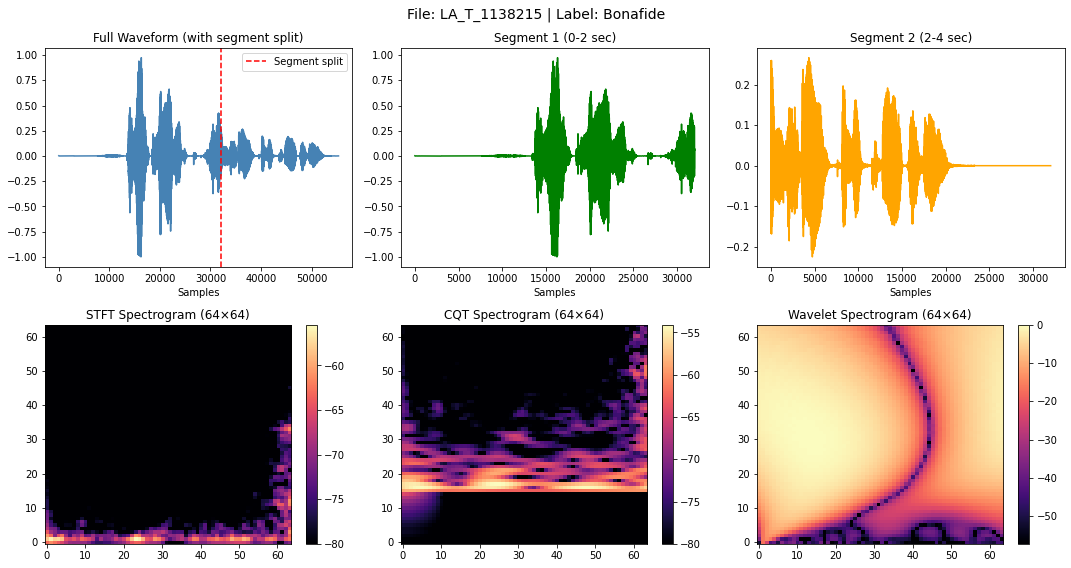

✅ Visualization saved!


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Load one sample file
sample_file = "LA_T_1138215"
sample_path = os.path.join(TRAIN_AUDIO, sample_file + ".flac")

waveform, sr = torchaudio.load(sample_path)
segments = segment_audio(waveform, sr)

# Compute spectrograms for first segment
stft = compute_stft(segments[0], sr)
cqt  = compute_cqt(segments[0], sr)
wav  = compute_wavelet(segments[0])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1 — Full waveform + 2 segments
axes[0, 0].plot(waveform[0].numpy(), color='steelblue')
axes[0, 0].axvline(x=32000, color='red', linestyle='--', label='Segment split')
axes[0, 0].set_title("Full Waveform (with segment split)")
axes[0, 0].set_xlabel("Samples")
axes[0, 0].legend()

axes[0, 1].plot(segments[0][0].numpy(), color='green')
axes[0, 1].set_title("Segment 1 (0-2 sec)")
axes[0, 1].set_xlabel("Samples")

axes[0, 2].plot(segments[1][0].numpy(), color='orange')
axes[0, 2].set_title("Segment 2 (2-4 sec)")
axes[0, 2].set_xlabel("Samples")

# Row 2 — Spectrograms
im1 = axes[1, 0].imshow(stft, aspect='auto', origin='lower', cmap='magma')
axes[1, 0].set_title("STFT Spectrogram (64×64)")
plt.colorbar(im1, ax=axes[1, 0])

im2 = axes[1, 1].imshow(cqt, aspect='auto', origin='lower', cmap='magma')
axes[1, 1].set_title("CQT Spectrogram (64×64)")
plt.colorbar(im2, ax=axes[1, 1])

im3 = axes[1, 2].imshow(wav, aspect='auto', origin='lower', cmap='magma')
axes[1, 2].set_title("Wavelet Spectrogram (64×64)")
plt.colorbar(im3, ax=axes[1, 2])

plt.suptitle(f"File: {sample_file} | Label: Bonafide", fontsize=14)
plt.tight_layout()
plt.savefig("spectrogram_visualization.png", dpi=150)
plt.show()
print("✅ Visualization saved!")